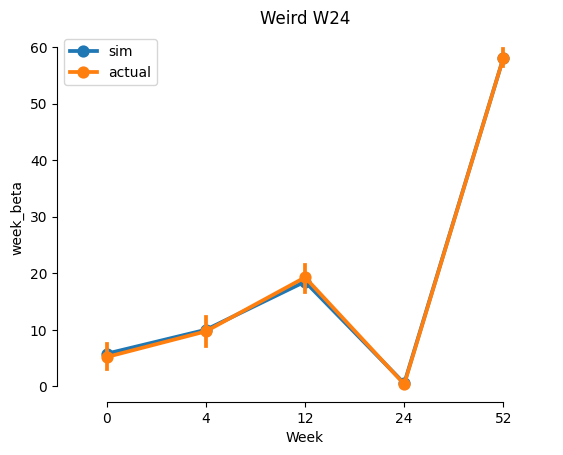

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from simulations import simulations as sim

df = sim.y_sim()
y_df = sim.y_kill(df, size = 50)

# screw up W24
y_df.loc[y_df.Week == 24, 'mean'] = np.random.rand(len(y_df[(y_df.Week == 24)]['mean']))

result24 = sim.lme_results(y_df)

sns.pointplot(data = result24, x = 'Week', y = 'week_beta', label = 'sim')
sns.pointplot(data = y_df, x = 'Week', y = 'y', label = 'actual')

plt.legend()
sns.despine(trim = True)
plt.title("Weird W24")
plt.show()

<ErrorbarContainer object of 3 artists>

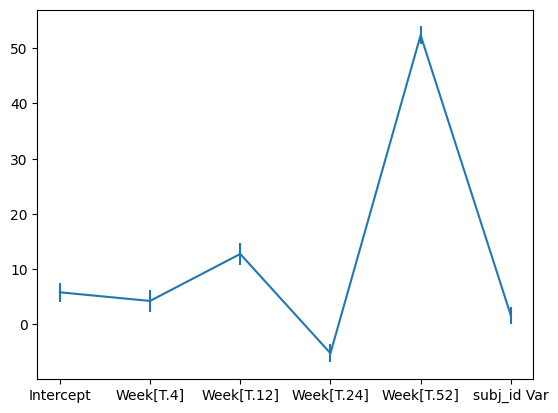

In [ ]:
import statsmodels.formula.api as smf

model = smf.mixedlm('y~Week', data = y_df, groups = 'subj_id').fit(maxiter = 400)

ci = model.conf_int()
yerr_lower = model.params - ci[0]
yerr_upper = ci[1] - model.params
plt.errorbar(model.params.index, model.params, yerr=[yerr_lower, yerr_upper])

In [3]:
#weeks = ['Week[T.4]', 'Week[T.12]', 'Week[T.24]', 'Week[T.52]']
weeks = model.fe_params.index
cov_matrix = model.cov_params()
var_int = model.bse['Intercept']

se_weeks = []
for week in weeks:
    var_week = model.bse[f'{week}']
    cov_int_week = cov_matrix.loc['Intercept', f'{week}']
    se_weeks.append(np.sqrt(var_int + var_week + (2*cov_int_week)))


In [24]:
def se_vals(model):
    weeks = model.fe_params.index
    cov_matrix = model.cov_params()
    var_int = model.bse['Intercept']

    se_weeks = []
    for week in weeks:
        var_week = model.bse[f'{week}']
        cov_int_week = cov_matrix.loc['Intercept', f'{week}']
        se_weeks.append(np.sqrt(var_int + var_week + (2*cov_int_week)))

    se_vals = np.zeros(5,)
    se_vals[0] = var_int
    se_vals[1:] = se_weeks[1:]
    
    return se_vals


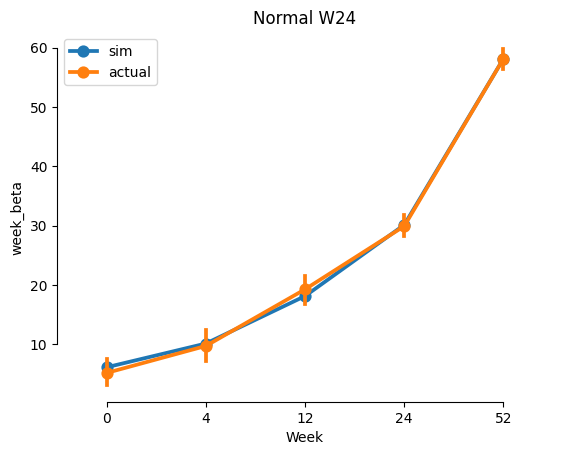

In [15]:
df = sim.y_sim()
y_df = sim.y_kill(df, size = 50)

result= sim.lme_results(y_df)

sns.pointplot(data = result, x = 'Week', y = 'week_beta', label = 'sim')
sns.pointplot(data = y_df, x = 'Week', y = 'y', label = 'actual')

plt.legend()
sns.despine(trim = True)
plt.title("Normal W24")
plt.show()